<a href="https://colab.research.google.com/github/Nevin-Thomas/cos781-data-mining-group-project/blob/dev/Improve_Text_Classification_With_Word_Embedding_Group_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
%pip install gensim

In [98]:
%pip install ijson

In [99]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import re, json, requests, random, nltk, gensim, torch, ijson
from concurrent import futures
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from transformers import AutoTokenizer, AutoModel
nltk.download('stopwords')
stop_words = nltk.corpus.stopwords.words('english')

print(" All core libraries loaded successfully")

 All core libraries loaded successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [100]:
# Stream Amazon Reviews Data

raw_urls = {
    'beauty': "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/All_Beauty.jsonl",
    'fashion': "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Amazon_Fashion.jsonl",
}
meta_urls = {
    'beauty': "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_All_Beauty.jsonl",
    'fashion': "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_Amazon_Fashion.jsonl",
}

def stream_amazon_review_json_file(url, limit=10000):
    """Stream JSONL data from HuggingFace"""
    rows = []
    try:
        res = requests.get(url, stream=True)
        res.raise_for_status()
        lines = (line.decode('utf-8') for line in res.iter_lines())
        for i, ln in enumerate(lines):
            if i > limit:
                break
            try:
                item = next(ijson.items(ln, '', multiple_values=True))
                rows.append(item)
            except Exception:
                continue
    except Exception as e:
        print(f"Stream error: {e}")
    return rows

def load_all_datasets(url_dict, nrows=10000):
    """Concurrent loader"""
    all_data = []
    with futures.ThreadPoolExecutor() as executor:
        futs = [executor.submit(stream_amazon_review_json_file, url, nrows) for url in url_dict.values()]
        for future in futures.as_completed(futs):
            try:
                all_data.extend(future.result())
            except Exception as e:
                print(f"Load failed: {e}")
    return all_data

reviews_raw = load_all_datasets(raw_urls, 10000)
meta_raw = load_all_datasets(meta_urls, 10000)

df_reviews = pd.DataFrame(reviews_raw)
df_meta = pd.DataFrame(meta_raw)

In [101]:
# Data cleaning

df_reviews = df_reviews.drop(['images','asin','user_id','timestamp','helpful_vote'], axis=1, errors='ignore')
df_meta = df_meta.drop(['bought_together','subtitle','author','videos','images','store','rating_number','categories','details','price'], axis=1, errors='ignore')

df_reviews = df_reviews.rename(columns={'title':'product_review_title', 'text':'review'})
df_meta = df_meta.rename(columns={'title':'product_title'})

df = pd.merge(df_reviews, df_meta, on='parent_asin', how='inner')
df = df.dropna().astype(str).drop_duplicates()

print(f" Combined dataset shape: {df.shape}")
print(df[['review','rating','product_title']].head())

 Combined dataset shape: (1336, 10)
                                              review rating  \
0  These were lightweight and soft but much too s...    3.0   
1  I really like these ear swabs. First they come...    5.0   
2  To be honest, I rarely have used an overnight ...    5.0   
3  its OK  not as good as the  original Wet Brush...    3.0   
4  I purchased these to see if I could set my mom...    5.0   

                                       product_title  
0  Niseyo new Faux Locs 24 Inch Crochet Hair 6 Pa...  
1  Organic Bamboo Cotton Ear Swabs by Bali Boo - ...  
2  Iryasa Night Indulge Cream - Natural Face Crea...  
3                      Original Detangler Hair Brush  
4             1/8 inch Snap On Rollers 8 Pack (Pink)  


In [102]:
# Text cleaning and labelling

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [w for w in text.split() if w not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["review"].apply(clean_text)

# Label sentiment based on rating
df["label"] = df["rating"].astype(float).apply(lambda x: "positive" if x >= 4 else ("negative" if x <= 2 else "neutral"))
df = df[df["label"] != "neutral"]  # drop neutrals for binary sentiment

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Evaluation function

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label="positive")
    rec = recall_score(y_true, y_pred, pos_label="positive")
    f1 = f1_score(y_true, y_pred, pos_label="positive")
    print(f"\n {name} RESULTS:")
    print(classification_report(y_true, y_pred))
    return [name, acc, prec, rec, f1]

results = []

In [103]:

# Baseline Models

## (a) BoW + Naive Bayes
bow = CountVectorizer(max_features=2000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
pred_bow = nb.predict(X_test_bow)
results.append(evaluate("BoW + Naive Bayes", y_test, pred_bow))

## (b) TF-IDF + Logistic Regression
tfidf = TfidfVectorizer(max_features=2000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_tfidf, y_train)
pred_tfidf = lr.predict(X_test_tfidf)
results.append(evaluate("TF-IDF + Logistic Regression", y_test, pred_tfidf))

## (c) Word2Vec + Random Forest
sentences = [t.split() for t in X_train]
w2v = gensim.models.Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)
def embed_w2v(text):
    words = [w for w in text.split() if w in w2v.wv]
    return np.mean([w2v.wv[w] for w in words], axis=0) if len(words) > 0 else np.zeros(100)
X_train_w2v = np.vstack([embed_w2v(t) for t in X_train])
X_test_w2v = np.vstack([embed_w2v(t) for t in X_test])
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42)
rf_w2v.fit(X_train_w2v, y_train)
pred_w2v = rf_w2v.predict(X_test_w2v)
results.append(evaluate("Word2Vec + Random Forest", y_test, pred_w2v))

## (d) GloVe + Random Forest

import os, zipfile, requests

# Download GloVe if not already downloaded
glove_dir = "glove"
os.makedirs(glove_dir, exist_ok=True)
glove_path = os.path.join(glove_dir, "glove.6B.100d.txt")

if not os.path.exists(glove_path):
    print(" Downloading GloVe embeddings (100d)...")
    url = "http://nlp.stanford.edu/data/glove.6B.zip"
    r = requests.get(url)
    with open(os.path.join(glove_dir, "glove.6B.zip"), "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(os.path.join(glove_dir, "glove.6B.zip"), "r") as zip_ref:
        zip_ref.extractall(glove_dir)
    print(" GloVe downloaded and extracted.")

# Load GloVe vectors into a dictionary
print(" Loading GloVe embeddings into memory...")
glove_embeddings = {}
with open(glove_path, 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector
print(f" Loaded {len(glove_embeddings):,} word vectors from GloVe.")

# Function to embed reviews using GloVe
def embed_glove(text):
    words = [w for w in text.split() if w in glove_embeddings]
    if len(words) == 0:
        return np.zeros(100)
    return np.mean([glove_embeddings[w] for w in words], axis=0)

# Generate GloVe embeddings for train/test
X_train_glove = np.vstack([embed_glove(t) for t in X_train])
X_test_glove = np.vstack([embed_glove(t) for t in X_test])

# Train and evaluate a classifier
rf_glove = RandomForestClassifier(n_estimators=100, random_state=42)
rf_glove.fit(X_train_glove, y_train)
pred_glove = rf_glove.predict(X_test_glove)

results.append(evaluate("GloVe + Random Forest", y_test, pred_glove))


## (e) BERT + Random Forest (fastest transformer test)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased")

def embed_bert(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[:,0,:].numpy().flatten()

X_train_bert = np.vstack([embed_bert(t) for t in X_train])  # Use all training data
X_test_bert = np.vstack([embed_bert(t) for t in X_test])    # Use all test data
rf_bert = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bert.fit(X_train_bert, y_train)
pred_bert = rf_bert.predict(X_test_bert)
results.append(evaluate("BERT + Random Forest", y_test, pred_bert))

## (d) FastText + Random Forest
print("\n Training FastText embeddings...")
from gensim.models import FastText

sentences = [t.split() for t in X_train]
ft_model = FastText(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    epochs=10,
    workers=4,
)
print(" FastText training complete")

def embed_fasttext(text):
    words = [w for w in text.split() if w in ft_model.wv]
    return np.mean([ft_model.wv[w] for w in words], axis=0) if len(words) > 0 else np.zeros(100)

# Generate embeddings
X_train_ft = np.vstack([embed_fasttext(t) for t in X_train])
X_test_ft  = np.vstack([embed_fasttext(t) for t in X_test])

# Classifier (use same one as Word2Vec for consistency)
rf_ft = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ft.fit(X_train_ft, y_train)
pred_ft = rf_ft.predict(X_test_ft)

# Evaluate
results.append(evaluate("FastText + Random Forest", y_test, pred_ft))



 BoW + Naive Bayes RESULTS:
              precision    recall  f1-score   support

    negative       0.56      0.20      0.30        44
    positive       0.88      0.97      0.92       257

    accuracy                           0.86       301
   macro avg       0.72      0.59      0.61       301
weighted avg       0.83      0.86      0.83       301


 TF-IDF + Logistic Regression RESULTS:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        44
    positive       0.85      1.00      0.92       257

    accuracy                           0.85       301
   macro avg       0.43      0.50      0.46       301
weighted avg       0.73      0.85      0.79       301



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 Word2Vec + Random Forest RESULTS:
              precision    recall  f1-score   support

    negative       1.00      0.02      0.04        44
    positive       0.86      1.00      0.92       257

    accuracy                           0.86       301
   macro avg       0.93      0.51      0.48       301
weighted avg       0.88      0.86      0.79       301

 Loading GloVe embeddings into memory...
 Loaded 400,000 word vectors from GloVe.

 GloVe + Random Forest RESULTS:
              precision    recall  f1-score   support

    negative       1.00      0.07      0.13        44
    positive       0.86      1.00      0.93       257

    accuracy                           0.86       301
   macro avg       0.93      0.53      0.53       301
weighted avg       0.88      0.86      0.81       301


 BERT + Random Forest RESULTS:
              precision    recall  f1-score   support

    negative       0.50      0.07      0.12        44
    positive       0.86      0.99      0.92       257



=== MODEL COMPARISON ===
                          Model  Accuracy  Precision    Recall        F1
0             BoW + Naive Bayes  0.860465   0.877193  0.972763  0.922509
1  TF-IDF + Logistic Regression  0.853821   0.853821  1.000000  0.921147
2      Word2Vec + Random Forest  0.857143   0.856667  1.000000  0.922801
3         GloVe + Random Forest  0.863787   0.862416  1.000000  0.926126
4          BERT + Random Forest  0.853821   0.861017  0.988327  0.920290
5      FastText + Random Forest  0.850498   0.855705  0.992218  0.918919


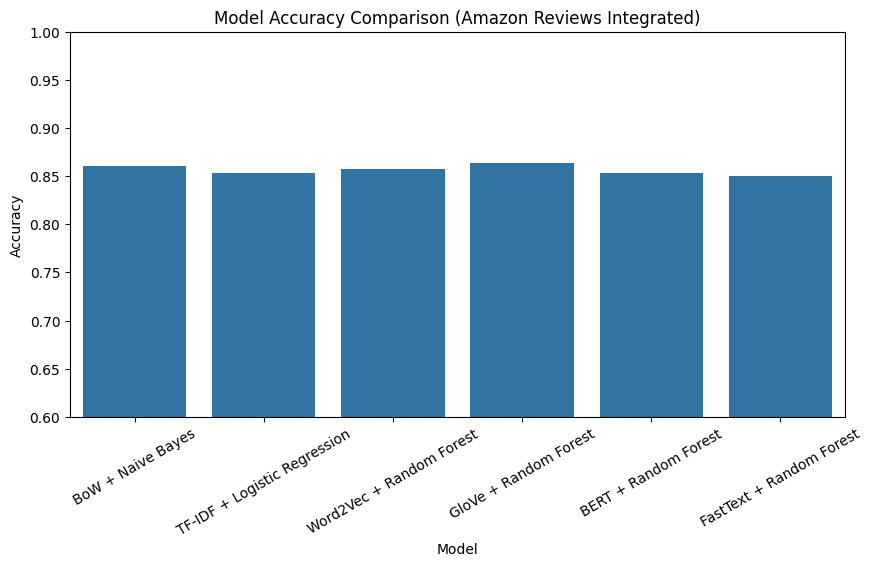

In [104]:
# Comparison results

df_results = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
print("\n=== MODEL COMPARISON ===")
print(df_results)

plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="Accuracy", data=df_results)
plt.title("Model Accuracy Comparison (Amazon Reviews Integrated)")
plt.xticks(rotation=30)
plt.ylim(0.6,1.0)
plt.show()

 K-Means done. Silhouette score: 0.464


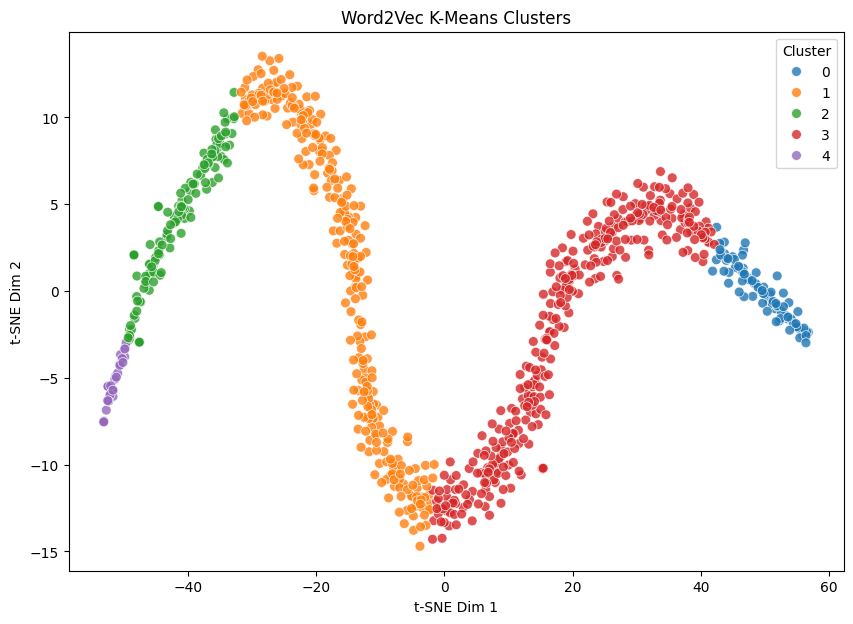

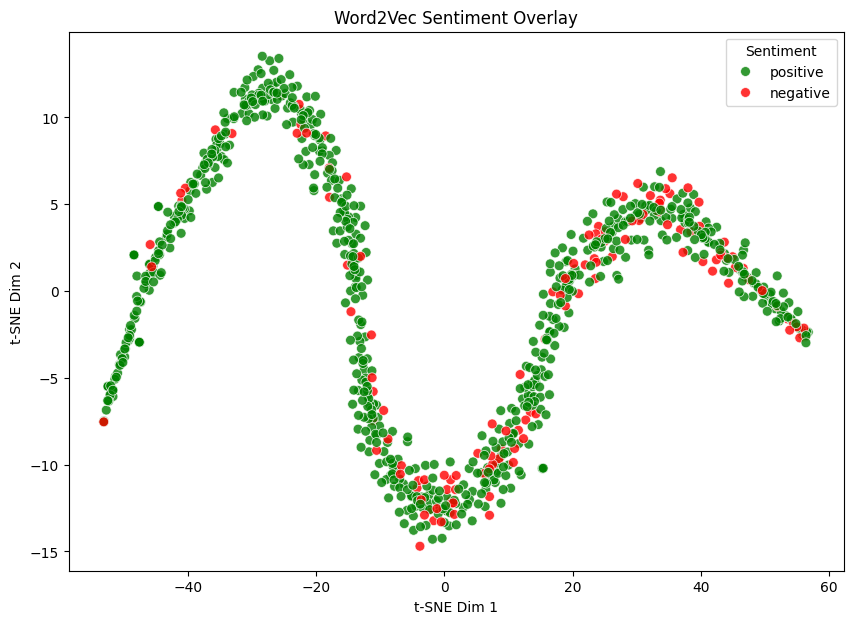

 Hierarchical clustering done (Ward linkage).


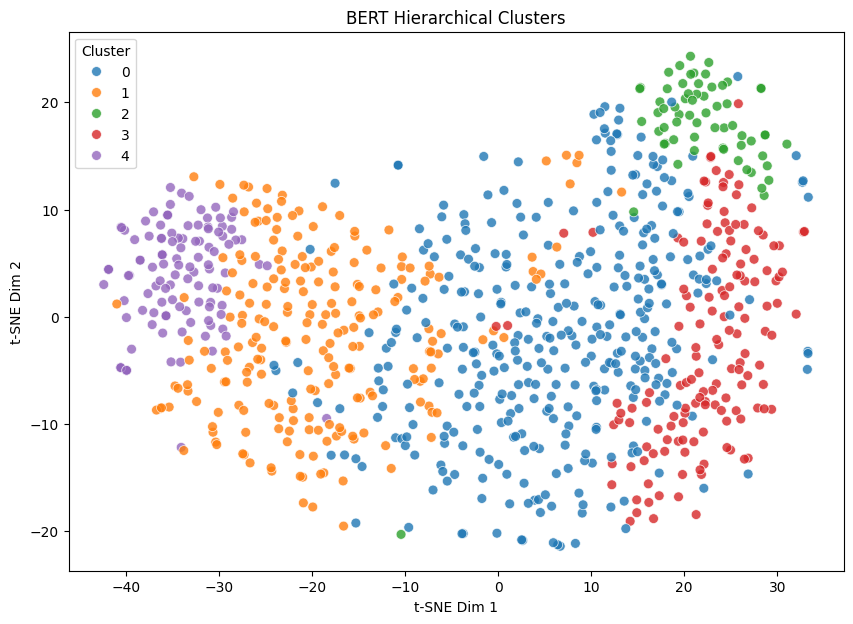

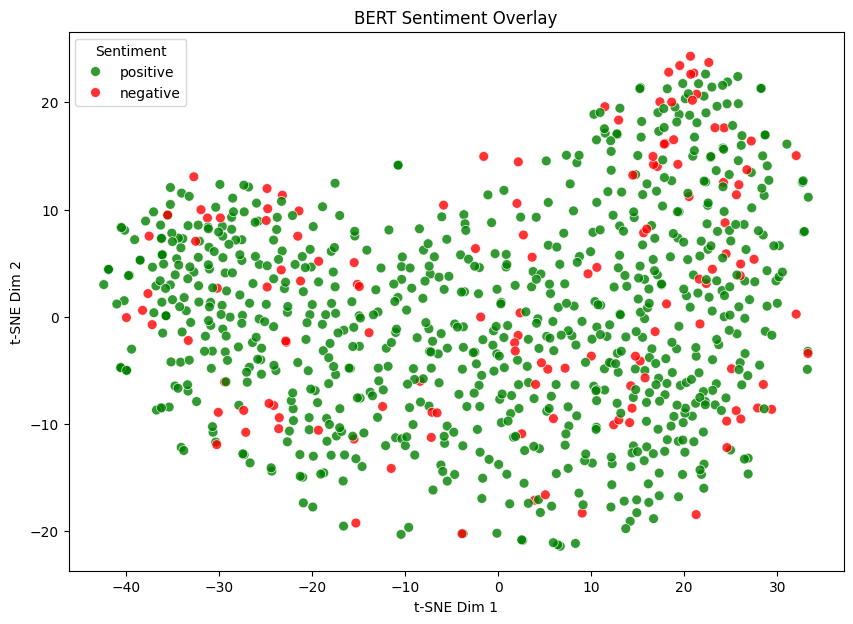

In [105]:

# Clustering module for the Amazon Review Embeddings

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Cluster embeddings

def cluster_embeddings(embeddings, method="hierarchical", n_clusters=5):
    """
    Cluster embeddings and return cluster labels.
    method: 'kmeans', 'hierarchical', 'graph'
    """
    if method == "hierarchical":
        # Filter zero vectors
        nonzero_idx = ~np.all(embeddings == 0, axis=1)
        labels = np.zeros(len(embeddings), dtype=int)
        if np.any(nonzero_idx):
            embeddings_filtered = embeddings[nonzero_idx]
            hier = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
            labels_filtered = hier.fit_predict(embeddings_filtered)
            labels[nonzero_idx] = labels_filtered
        print(" Hierarchical clustering done (Ward linkage).")
        return labels

    elif method == "kmeans":
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        print(f" K-Means done. Silhouette score: {silhouette_score(embeddings, labels):.3f}")
        return labels

    elif method == "graph":
        sim_matrix = cosine_similarity(embeddings)
        G = nx.Graph()
        for i in range(len(sim_matrix)):
            for j in range(i+1, len(sim_matrix)):
                if sim_matrix[i,j] > 0.8: # similarity threshold
                    G.add_edge(i,j,weight=sim_matrix[i,j])

        labels = np.zeros(len(embeddings), dtype=int)
        try:
            import community as community_louvain
            if len(G.edges) > 0:
                partition = community_louvain.best_partition(G)
                for node, cluster_id in partition.items():
                    labels[node] = cluster_id
        except ImportError:
            print(" 'python-louvain' not installed. Using connected components instead.")
            for i, comp in enumerate(nx.connected_components(G)):
                for node in comp:
                    labels[node] = i

        print(" Graph-based clustering done.")
        return labels
    else:
        raise ValueError("Method must be 'kmeans', 'hierarchical', or 'graph'.")

# Cluster + train classifier

def cluster_and_train(X_train_emb, X_test_emb, y_train, y_test, method="kmeans", n_clusters=5, classifier=None):
    # Cluster embeddings
    train_clusters = cluster_embeddings(X_train_emb, method, n_clusters)
    test_clusters = cluster_embeddings(X_test_emb, method, n_clusters)

    # LabelEncoder to handle unseen cluster IDs in test
    all_clusters = np.concatenate([train_clusters, test_clusters])
    le = LabelEncoder()
    le.fit(all_clusters)
    train_clusters_enc = le.transform(train_clusters)
    test_clusters_enc = le.transform(test_clusters)

    # Add cluster label as feature
    X_train_new = np.hstack([X_train_emb, train_clusters_enc.reshape(-1,1)])
    X_test_new = np.hstack([X_test_emb, test_clusters_enc.reshape(-1,1)])

    # Train classifier
    clf = classifier if classifier else RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_new, y_train)
    y_pred = clf.predict(X_test_new)

    return evaluate(f"{method.capitalize()} + Classifier", y_test, y_pred)

# 2D t-SNE visualization

def visualize_clusters(embeddings, labels, title="Cluster Visualization", perplexity=30, random_state=42):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init='pca', learning_rate='auto')
    X_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=labels, palette="tab10", s=50, alpha=0.8)
    plt.title(title)
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.legend(title="Cluster", loc='best')
    plt.show()

# Sentiment overlay visualization

def visualize_sentiment_overlay(embeddings, sentiment_labels, title="Sentiment Overlay", perplexity=30, random_state=42):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init='pca', learning_rate='auto')
    X_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x=X_2d[:,0], y=X_2d[:,1],
        hue=sentiment_labels,
        palette={"positive":"green", "negative":"red"},
        s=50, alpha=0.8
    )
    plt.title(title)
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.legend(title="Sentiment", loc='best')
    plt.show()

# Word2Vec embeddings
w2v_labels_kmeans = cluster_embeddings(X_train_w2v, method="kmeans", n_clusters=5)
visualize_clusters(X_train_w2v, w2v_labels_kmeans, title="Word2Vec K-Means Clusters")
visualize_sentiment_overlay(X_train_w2v, y_train.tolist(), title="Word2Vec Sentiment Overlay")

# BERT embeddings
bert_labels_hier = cluster_embeddings(X_train_bert, method="hierarchical", n_clusters=5)
visualize_clusters(X_train_bert, bert_labels_hier, title="BERT Hierarchical Clusters")
visualize_sentiment_overlay(X_train_bert, y_train.tolist(), title="BERT Sentiment Overlay")

# SVm

In [106]:
from sklearn.metrics import roc_auc_score,classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC

In [107]:
df['label_binary'] = df['label'].apply(lambda x: 1 if x=='positive' else 0)
X = df['clean_text']
y = df['label_binary']
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=20000)
X_tfidf = tfidf.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.25, stratify=y, random_state=11)

In [108]:
mod = SVC(random_state=42)


### Regularization

In [109]:
mod_reg = SVC(C=0.1)
mod_reg.fit(X_train,y_train)
print(f'A regularization test score with a C=0.1 is score={mod_reg.score(X_test,y_test)}')
mod_reg = SVC(C=1)
mod_reg.fit(X_train,y_train)
print(f'A regularization test score with a C=0.1 is score={mod_reg.score(X_test,y_test)}')
mod_reg = SVC(C=1000)
mod_reg.fit(X_train,y_train)
print(f'A regularization test score with a C=1000 is score={mod_reg.score(X_test,y_test)}')

A regularization test score with a C=0.1 is score=0.8538205980066446
A regularization test score with a C=0.1 is score=0.8538205980066446
A regularization test score with a C=1000 is score=0.8538205980066446


### Gamma

In [110]:
mod_gamma = SVC(gamma=0.1)
mod_gamma.fit(X_train,y_train)
print(f'A gamma test score with a gamma=0.1 is score={mod_gamma.score(X_test,y_test)}')
mod_gamma = SVC(gamma=1)
mod_gamma.fit(X_train,y_train)
print(f'A gamma test score with a gamma=1 is score={mod_gamma.score(X_test,y_test)}')
mod_gamma = SVC(gamma=1000)
mod_gamma.fit(X_train,y_train)
print(f'A gamma test score with a gamma=1000 is score={mod_gamma.score(X_test,y_test)}')

A gamma test score with a gamma=0.1 is score=0.8538205980066446
A gamma test score with a gamma=1 is score=0.8538205980066446
A gamma test score with a gamma=1000 is score=0.8538205980066446


### Grid Search Cross-Validation

In [111]:
#variable setup for tests
parameters_for_tests = {
    'kernel':['linear','rbf'],
    'gamma':[1000,100,1,0.1,0.01,0.001],
    'C':[1000,100,1,0.1,0.01,0.001]
    }

grid=GridSearchCV(
    estimator=mod,
    param_grid=parameters_for_tests,
    scoring='accuracy',
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [112]:
grid.fit(X_train,y_train)
verdict_estimator = grid.best_estimator_
print(f'Best parameters {grid.best_params_}')
print(f'Best cross validation score: {grid.best_score_:.4f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross validation score: 0.8749


### Score & Report

In [113]:
predicted_y = verdict_estimator.predict(X_test)
probable_y= verdict_estimator.decision_function(X_test)

In [114]:
print(classification_report(y_test,predicted_y))

              precision    recall  f1-score   support

           0       1.00      0.16      0.27        44
           1       0.87      1.00      0.93       257

    accuracy                           0.88       301
   macro avg       0.94      0.58      0.60       301
weighted avg       0.89      0.88      0.84       301



In [115]:
roc_auc = roc_auc_score(y_test,probable_y)
print(f'ROC AUC Score: {roc_auc:.4f}')

ROC AUC Score: 0.8690


In [116]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import numpy as np
import pandas as pd

In [117]:
knn_pipeline = Pipeline([
    ("norm", Normalizer()), # L2-normalize embedding vectors
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        metric="cosine",
        weights="distance" # can try "uniform" as well
    ))
])

# Train
knn_pipeline.fit(X_train, y_train)

# Predict
y_pred_knn = knn_pipeline.predict(X_test)

In [118]:
acc = accuracy_score(y_test, y_pred_knn)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_knn, average="weighted", zero_division=0)

print(f" KNN results — k=5, metric=cosine, weights=distance")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}\n")

print("Classification report (per class):")
print(classification_report(y_test, y_pred_knn, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_knn))

 KNN results — k=5, metric=cosine, weights=distance
Accuracy:  0.8771
Precision: 0.8704
Recall:    0.8771
F1-score:  0.8439

Classification report (per class):
              precision    recall  f1-score   support

           0       0.82      0.20      0.33        44
           1       0.88      0.99      0.93       257

    accuracy                           0.88       301
   macro avg       0.85      0.60      0.63       301
weighted avg       0.87      0.88      0.84       301

Confusion matrix:
[[  9  35]
 [  2 255]]


In [119]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["cosine", "minkowski"], # you can try p=[1,2]
}

knn_base = Pipeline([
    ("norm", Normalizer()),
    ("knn", KNeighborsClassifier())
])

grid = GridSearchCV(
    knn_base,
    param_grid=param_grid,
    scoring="f1_weighted", # or "accuracy"
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Evaluate best model on test set
best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test)

acc_b = accuracy_score(y_test, y_pred_best)
prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(y_test, y_pred_best, average="weighted", zero_division=0)

print("\n Best KNN (GridSearchCV) — test metrics")
print(f"Accuracy:  {acc_b:.4f}")
print(f"Precision: {prec_b:.4f}")
print(f"Recall:    {rec_b:.4f}")
print(f"F1-score:  {f1_b:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'knn__metric': 'cosine', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Best CV score: 0.8504468400470051

 Best KNN (GridSearchCV) — test metrics
Accuracy:  0.8837
Precision: 0.8707
Recall:    0.8837
F1-score:  0.8633


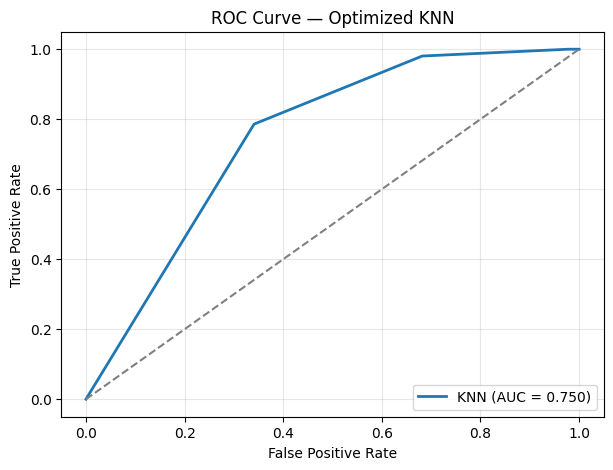

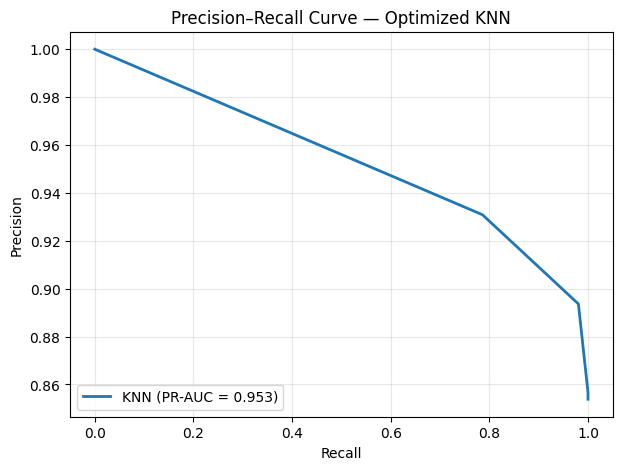

In [120]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc
import numpy as np

# Compute probabilities if available
if hasattr(best_knn, "predict_proba"):
    y_proba = best_knn.predict_proba(X_test)[:, 1]
else:
    # fallback if predict_proba is not available
    y_distances, _ = best_knn.kneighbors(X_test)
    y_proba = 1 / (1 + np.mean(y_distances, axis=1))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test.astype(int), y_proba)
roc_auc = roc_auc_score(y_test.astype(int), y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"KNN (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Optimized KNN")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Precision–Recall Curve
prec, rec, _ = precision_recall_curve(y_test.astype(int), y_proba)
pr_auc = auc(rec, prec)

plt.figure(figsize=(7, 5))
plt.plot(rec, prec, label=f"KNN (PR-AUC = {pr_auc:.3f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Optimized KNN")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()